In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os
os.listdir('/content/drive/MyDrive')

['athul.JPG',
 'Colab Notebooks',
 'Classroom',
 'Cassava Project',
 'Athul V',
 'Athul_V_Data_Scientist.pdf',
 'ATHUL REPORT .pdf',
 'Detailed Transformer Block Architecture.docx',
 'Athul_LLM_slides.docx',
 'Athul_LLM_slides.gdoc',
 '.ipynb_checkpoints',
 'Note-Taking App Development Research\n.gdoc',
 'MCA Docu',
 'Ananya_articleship.gdoc',
 'holistic-mvp',
 'Share',
 'Mstock Tracker.gsheet',
 'WebRTC: Real-Time Communication for the Web.gslides',
 'WebRTC.gslides',
 'Untitled.gdoc',
 'V_Athul_Resume_5-05-2026.pdf',
 'bfdfc2ad-6fa2-42ef-9b74-871f16362837.JPG',
 'Copy of Athul_V_Data_Scientist.gdoc',
 'Create mock data for ai training based on the ext....gsheet',
 'Graduation ',
 'Student-focused app stand out and pr....gdoc',
 'how to monitor? the usage and how to set the pro....gdoc',
 'azure-ai-foundry-foundry.pdf',
 'Voice Clone TTS STT.gdoc',
 'data-privacy.pdf',
 '2.gsheet',
 '3.gsheet',
 '4.gsheet',
 '1.gsheet',
 'names.pdf',
 'WebForm Automator.gdoc',
 'Saved from the Google 

In [5]:
file_path = "/content/drive/MyDrive/Car Price Prediction/car_prediction_data.csv"

In [6]:
import pandas as pd

df = pd.read_csv(file_path)
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [7]:
print("Shape", df.shape)
df.info()

Shape (301, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [8]:
df["Selling_Price"]

,Selling_Price
0,3.35
1,4.75
2,7.25
3,2.85
4,4.60
...,...
296,9.50
297,4.00
298,3.35
299,11.50


In [9]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [10]:
df.duplicated().sum()

np.int64(2)

In [11]:
df[df.duplicated()]

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
17,ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
93,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0


In [12]:
df[df.duplicated(keep=False)]

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
15,ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
17,ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
51,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0
93,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0


In [13]:
df = df.drop_duplicates()

In [14]:
df.shape

(299, 9)

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df["Selling_Price"].describe()

,Selling_Price
count,299.000000
mean,4.589632
std,4.984240
min,0.100000
25%,0.850000
50%,3.510000
75%,6.000000
max,35.000000


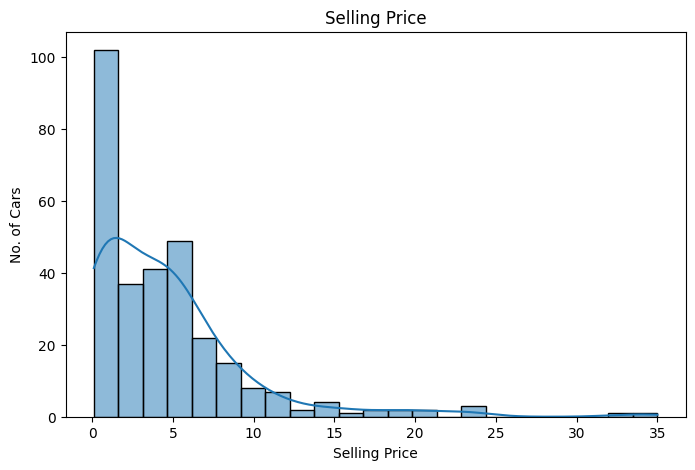

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df['Selling_Price'], kde=True)

plt.title("Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("No. of Cars")
plt.show()

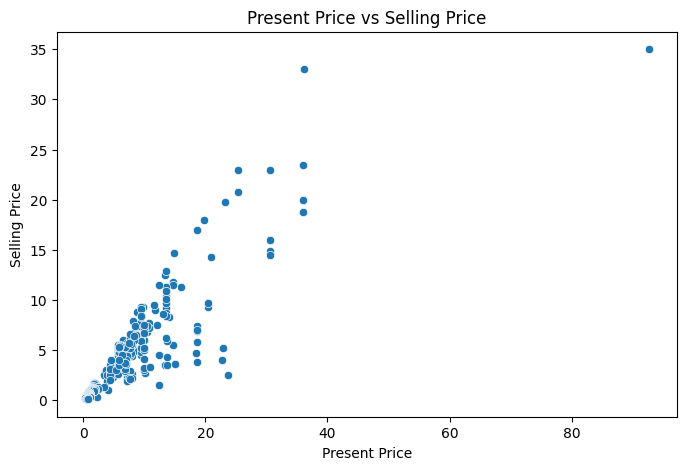

In [19]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Present_Price",
    y="Selling_Price"
)

plt.title("Present Price vs Selling Price")
plt.xlabel("Present Price")
plt.ylabel("Selling Price")

plt.show()

In [21]:
df.shape

(299, 9)

In [22]:
df["Selling_Price"].describe()

,Selling_Price
count,299.000000
mean,4.589632
std,4.984240
min,0.100000
25%,0.850000
50%,3.510000
75%,6.000000
max,35.000000


### What are Outliers?

**Outliers** are data points that significantly deviate from other observations in a dataset. They are extreme values that lie an abnormal distance from other values in a random sample from a population. In simple terms, they are data points that "stand out" from the rest of the data.

#### Why are Outliers Important?

Outliers can have a significant impact on data analysis and machine learning models:

1.  **Skew Statistics**: They can distort statistical measures like the mean, standard deviation, and variance. For instance, a single very large outlier can drastically inflate the mean, making it a misleading representation of the central tendency.
2.  **Affect Model Performance**: Many machine learning algorithms (especially those based on distances or assumptions of normality, like Linear Regression) are sensitive to outliers. Outliers can lead to biased model parameters, reduced accuracy, and overfitting, making the model perform poorly on new, unseen data.
3.  **Indicate Anomalies**: Sometimes, outliers represent genuinely rare events, errors in data collection, or unusual circumstances. Identifying and investigating them can reveal important insights or data quality issues.

#### How to Detect Outliers?

Several methods can be used to detect outliers, both statistically and visually:

*   **Visual Methods**:
    *   **Box Plots**: As shown in the cell below, box plots (or box-and-whisker plots) graphically display the distribution of numerical data and identify potential outliers as individual points beyond the "whiskers." The whiskers typically extend to 1.5 times the Interquartile Range (IQR) from the first (Q1) and third (Q3) quartiles.
    *   **Histograms/Scatter Plots**: These can also help visualize unusual data points or clusters that are far from the main body of data.

*   **Statistical Methods**:
    *   **Z-score**: Measures how many standard deviations away a data point is from the mean. Data points with a Z-score above a certain threshold (e.g., 2 or 3) can be considered outliers.
    *   **IQR (Interquartile Range) Method**: Defines outliers as values that fall below `Q1 - 1.5 * IQR` or above `Q3 + 1.5 * IQR`.
    *   **Isolation Forest**: An unsupervised learning algorithm that isolates anomalies by randomly selecting a feature and then randomly selecting a split value between the maximum and minimum values of the selected feature.
    *   **Local Outlier Factor (LOF)**: A density-based outlier detection algorithm that measures the local deviation of a given data point with respect to its neighbors.

#### Handling Outliers:

Once detected, how to handle outliers depends on their cause and the specific problem:

*   **Removal**: If outliers are due to data entry errors or corruption, they can be removed from the dataset. However, this should be done cautiously, as removing valid data can lead to loss of information.
*   **Transformation**: Applying mathematical transformations (e.g., logarithmic, square root) can reduce the impact of extreme values and make the data distribution more normal.
*   **Imputation**: Replacing outliers with a more representative value (e.g., the mean, median, or a value from a specific quantile) can be an option.
*   **Binning**: Grouping numerical data into bins can smooth out the effect of outliers.
*   **Robust Models**: Using machine learning models that are less sensitive to outliers (e.g., tree-based models like Random Forest, or robust regression methods) can be an alternative to modifying the data.

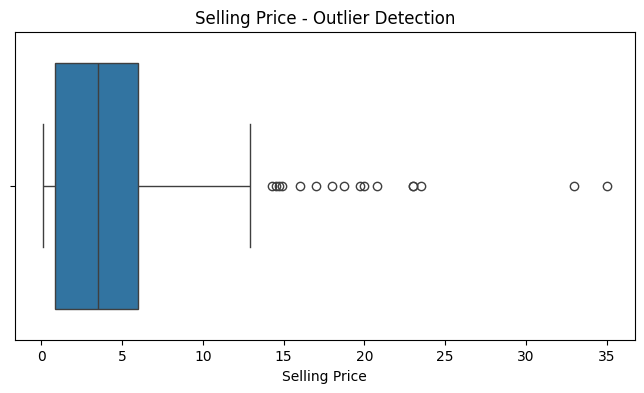

In [24]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["Selling_Price"])

plt.title("Selling Price - Outlier Detection")
plt.xlabel("Selling Price")

plt.show()

For the first model, we can remove the Selling Price and Name of the Car

In [25]:
X = df.drop(["Selling_Price", "Car_Name"], axis=1)
y = df["Selling_Price"]

In [29]:
print("Now the X:", X)

Now the X:      Year  Present_Price  Kms_Driven Fuel_Type Seller_Type Transmission  Owner
0    2014           5.59       27000    Petrol      Dealer       Manual      0
1    2013           9.54       43000    Diesel      Dealer       Manual      0
2    2017           9.85        6900    Petrol      Dealer       Manual      0
3    2011           4.15        5200    Petrol      Dealer       Manual      0
4    2014           6.87       42450    Diesel      Dealer       Manual      0
..    ...            ...         ...       ...         ...          ...    ...
296  2016          11.60       33988    Diesel      Dealer       Manual      0
297  2015           5.90       60000    Petrol      Dealer       Manual      0
298  2009          11.00       87934    Petrol      Dealer       Manual      0
299  2017          12.50        9000    Diesel      Dealer       Manual      0
300  2016           5.90        5464    Petrol      Dealer       Manual      0

[299 rows x 7 columns]


In [30]:
print("Now the y:", y)

Now the y: 0       3.35
1       4.75
2       7.25
3       2.85
4       4.60
       ...  
296     9.50
297     4.00
298     3.35
299    11.50
300     5.30
Name: Selling_Price, Length: 299, dtype: float64


Instead of relying only on Year, we can create a more intuitive feature:

In [31]:
df["Car_Age"] = 2026 - df["Year"]

In [35]:
X = df.drop(
    ["Selling_Price", "Car_Name"],
    axis=1
)

y = df["Selling_Price"]

In [36]:
print(X)

     Year  Present_Price  Kms_Driven Fuel_Type Seller_Type Transmission  \
0    2014           5.59       27000    Petrol      Dealer       Manual   
1    2013           9.54       43000    Diesel      Dealer       Manual   
2    2017           9.85        6900    Petrol      Dealer       Manual   
3    2011           4.15        5200    Petrol      Dealer       Manual   
4    2014           6.87       42450    Diesel      Dealer       Manual   
..    ...            ...         ...       ...         ...          ...   
296  2016          11.60       33988    Diesel      Dealer       Manual   
297  2015           5.90       60000    Petrol      Dealer       Manual   
298  2009          11.00       87934    Petrol      Dealer       Manual   
299  2017          12.50        9000    Diesel      Dealer       Manual   
300  2016           5.90        5464    Petrol      Dealer       Manual   

     Owner  Car_Age  
0        0       12  
1        0       13  
2        0        9  
3        0 

ML Algo don't directly understand the categories, so we need to convert those categories into numbers. This process is called **Encoding**

In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = ["Fuel_Type", "Seller_Type", "Transmission"]

numerical_features = ["Present_Price", "Kms_Driven", "Car_Age"]

In [38]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

**Split the data**

Now comes a very important ML concept.

We don't train and evaluate using the same data.

We divide the dataset into Test_data and Train_data

Training data:

The model learns from this.

Testing data:

We use this to see how well the model works on unseen data.

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [40]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (239, 8)
X_test : (60, 8)
y_train: (239,)
y_test : (60,)


In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

linear_model = Pipeline(
    steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [42]:
linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Fuel_Type', 'Seller_Type',
                                                   'Transmission']),
                                                 ('numerical', 'passthrough',
                                                  ['Present_Price',
                                                   'Kms_Driven',
                                                   'Car_Age'])])),
                ('model', LinearRegression())])

`model.fit` means Learn the relationship between the car features (X_train) and their known prices (y_train).

In [44]:
y_pred = linear_model.predict(X_test)
print("y_pred:", y_pred)

y_pred: [ 7.50043163  7.81104111  1.39768641  7.02450491 11.16047067  4.54274802
  8.48533905  1.72657222  8.83514448 -0.93076493 10.36489038 -0.90512352
  0.78692512  1.55004622  4.33534603  5.03737903  1.31163219  1.87888311
 21.55899556  0.89080359  0.95766314  1.84793663  5.57803558  0.32257524
  6.28960954  7.82239771  8.69061953  1.19923758  4.86508228  4.91753376
  3.24063459  4.84118416  6.29830129  2.79799837  2.90103707  6.98878381
  1.29395527 -5.1824736   1.38985309 10.39543392  7.09129742  9.05494392
  1.65523848  4.04243706  1.00464913 -2.0618152   8.13392992  4.38900981
  5.65803497 -0.56306977  0.70221307  0.25259877  8.29539531  9.46053879
  7.29650266  6.25462523  3.73803669  3.43350117  9.57383045  9.163373  ]


Now Compare predictions with Actual prices

In [46]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
283,8.99,7.500432
267,8.35,7.811041
166,0.45,1.397686
9,7.45,7.024505
78,5.25,11.160471
280,5.25,4.542748
95,5.85,8.485339
111,1.15,1.726572
5,9.25,8.835144
175,0.38,-0.930765


In [47]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 1.4139931739111222
RMSE: 2.436948698228172
R²  : 0.7695782975941827


test the model with completely new Car

In [48]:
new_car = pd.DataFrame({
    "Year": [2021],
    "Car_Age": [5],
    "Present_Price": [8.5],
    "Kms_Driven": [25000],
    "Fuel_Type": ["Petrol"],
    "Seller_Type": ["Dealer"],
    "Transmission": ["Manual"],
    "Owner": [0]
})

In [49]:
new_pred_price = linear_model.predict(new_car)
print("Predicted Price:", new_pred_price)

Predicted Price: [7.48905694]


Eval the model

### Evaluate the Model: Understanding Performance Metrics

Model evaluation is a crucial step to understand how well our trained model performs on unseen data. We use several metrics to assess the accuracy and reliability of our car price prediction model.

*   **Mean Absolute Error (MAE)**:
    *   **Definition**: MAE is the average of the absolute differences between the predicted values and the actual values. It measures the average magnitude of the errors in a set of predictions, without considering their direction.
    *   **Significance**: MAE is easy to understand because it's in the same units as the target variable (Selling Price in our case). A lower MAE indicates a more accurate model. For example, an MAE of 1.41 means, on average, our model's predictions are off by 1.41 lakh rupees from the actual selling price.

*   **Root Mean Squared Error (RMSE)**:
    *   **Definition**: RMSE is the square root of the average of the squared differences between predicted and actual values. It's a quadratic scoring rule that measures the average magnitude of the error.
    *   **Significance**: RMSE penalizes larger errors more heavily than MAE due to the squaring of differences. This makes it sensitive to outliers. Like MAE, a lower RMSE indicates better model performance. It is also in the same units as the target variable.

*   **R-squared (R²)**:
    *   **Definition**: R-squared, also known as the coefficient of determination, measures the proportion of the variance in the dependent variable (Selling Price) that can be predicted from the independent variables (features). It ranges from 0 to 1.
    *   **Significance**: An R² of 1 indicates that the model explains all the variability of the response data around its mean. An R² of 0 indicates that the model explains no variability of the response data around its mean. In our case, an R² of 0.769 suggests that approximately 76.9% of the variance in car selling prices can be explained by our model's features, which is a reasonably good fit.

In [51]:
y_pred = linear_model.predict(X_test)
print("y_pred:", y_pred)

y_pred: [ 7.50043163  7.81104111  1.39768641  7.02450491 11.16047067  4.54274802
  8.48533905  1.72657222  8.83514448 -0.93076493 10.36489038 -0.90512352
  0.78692512  1.55004622  4.33534603  5.03737903  1.31163219  1.87888311
 21.55899556  0.89080359  0.95766314  1.84793663  5.57803558  0.32257524
  6.28960954  7.82239771  8.69061953  1.19923758  4.86508228  4.91753376
  3.24063459  4.84118416  6.29830129  2.79799837  2.90103707  6.98878381
  1.29395527 -5.1824736   1.38985309 10.39543392  7.09129742  9.05494392
  1.65523848  4.04243706  1.00464913 -2.0618152   8.13392992  4.38900981
  5.65803497 -0.56306977  0.70221307  0.25259877  8.29539531  9.46053879
  7.29650266  6.25462523  3.73803669  3.43350117  9.57383045  9.163373  ]


### Resources: Essential Tools and Libraries

In machine learning projects, 'resources' refer to the various tools, libraries, and frameworks that facilitate data handling, model development, and evaluation. For this car price prediction project, we primarily rely on the following Python libraries:

*   **`pandas`**: A powerful library for data manipulation and analysis. It provides data structures like DataFrames, which are essential for storing and processing tabular data.
*   **`numpy`**: The fundamental package for numerical computation in Python. It's often used implicitly by other libraries like pandas and scikit-learn for array operations.
*   **`matplotlib.pyplot`**: A comprehensive library for creating static, animated, and interactive visualizations in Python. We use it to create plots like histograms and scatter plots.
*   **`seaborn`**: A data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics, such as `histplot` and `scatterplot`.
*   **`sklearn` (scikit-learn)**: A widely used open-source machine learning library. It provides various classification, regression, and clustering algorithms, along with utilities for data preprocessing (e.g., `OneHotEncoder`, `ColumnTransformer`), model selection (e.g., `train_test_split`), and model evaluation (e.g., `mean_absolute_error`, `mean_squared_error`, `r2_score`).

These resources are critical for every step of the machine learning workflow, from initial data loading and exploration to model training and performance assessment.